<a href="https://colab.research.google.com/github/sa8692/Silver-Gold-Ratio-Trade/blob/main/Mean%20Ratio%20by%20Each%20Economic%20Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Correlation between gsr and recessions/fed rates
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas_datareader.data import DataReader
from datetime import datetime
import seaborn as sns
import statistics as stats

In [ ]:
start = "1970-01-01"
end   = datetime.today().strftime("%Y-%m-%d")

In [ ]:
gold = pd.read_csv("gold_historical.csv")
silver = pd.read_csv("silver_historical.csv")

#index_drop = gold.index[gold['Date'] == '01/01/1970']
#gold = gold.iloc[index_drop.astype(int)[0]:]
#silver = silver.iloc[index_drop.astype(int)[0]:]
#gold = gold.iloc[:-1]
#silver = silver.iloc[:-1]

#gold.index = gold['Date']
df = pd.DataFrame({
    'Gold': gold['Value'],
    'Silver': silver['Value'],
    'Gold/Silver Ratio': gold['Value']/silver['Value']}
    )
df.index = pd.to_datetime(gold['Date'])
df

,Gold,Silver,Gold/Silver Ratio
Date,,,
1915-01-01,19.2500,0.5100,37.745098
1915-02-01,19.2500,0.5100,37.745098
1915-03-01,19.2500,0.5100,37.745098
1915-04-01,19.2500,0.5100,37.745098
1915-05-01,19.2500,0.5100,37.745098
...,...,...,...
2025-05-01,3289.5548,32.9896,99.714904
2025-06-01,3266.4101,35.7821,91.286149
2025-07-01,3285.7772,37.1164,88.526290


In [ ]:
normalized_df = df[df.index >= '1970-01-01']
normalized_gs_ratio = normalized_df['Gold/Silver Ratio']/normalized_df['Gold/Silver Ratio'][0]
normalized_df['Normalized Gold/Silver Ratio'] = normalized_gs_ratio
normalized_df

/tmp/ipython-input-1727144323.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalized_gs_ratio = normalized_df['Gold/Silver Ratio']/normalized_df['Gold/Silver Ratio'][0]
/tmp/ipython-input-1727144323.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normalized_df['Normalized Gold/Silver Ratio'] = normalized_gs_ratio


,Gold,Silver,Gold/Silver Ratio,Normalized Gold/Silver Ratio
Date,,,,
1970-01-01,34.9800,1.9100,18.314136,1.000000
1970-02-01,35.0000,1.9000,18.421053,1.005838
1970-03-01,35.3000,1.8800,18.776596,1.025252
1970-04-01,35.8500,1.7200,20.843023,1.138084
1970-05-01,35.5000,1.6300,21.779141,1.189198
...,...,...,...,...
2025-05-01,3289.5548,32.9896,99.714904,5.444696
2025-06-01,3266.4101,35.7821,91.286149,4.984464
2025-07-01,3285.7772,37.1164,88.526290,4.833768


In [ ]:
raw_vol = stats.stdev(normalized_df['Gold/Silver Ratio'])
raw_vol

19.368495671021428

In [ ]:
normalized_vol = stats.stdev(normalized_df['Normalized Gold/Silver Ratio'])
normalized_vol

1.05757080422101

In [ ]:
recession_1973_df = df[df.index >= '1973-11-01']
recession_1973_df = recession_1973_df[recession_1973_df.index <= '1975-04-01']

In [ ]:
print('1973 Mean: ' + str(stats.mean(recession_1973_df['Gold/Silver Ratio'])))
print('1973 Variation: ' + str(stats.stdev(recession_1973_df['Gold/Silver Ratio'])))

1973 Mean: 35.743571087048416
1973 Variation: 4.286797934480832


In [ ]:
post_recession_1973_df = df[df.index >= '1975-04-01']
post_recession_1973_df = post_recession_1973_df[post_recession_1973_df.index <= '1977-09-01']

In [ ]:
print('1973 (Post-Recession) Mean: ' + str(stats.mean(post_recession_1973_df['Gold/Silver Ratio'])))
print('1973 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_1973_df['Gold/Silver Ratio'])))

1973 (Post-Recession) Mean: 31.227705623880173
1973 (Post-Recession) Variation: 3.279413418761414


In [ ]:
recession_1980_df = df[df.index >= '1980-01-01']
recession_1980_df = recession_1980_df[recession_1980_df.index <= '1980-07-01']

In [ ]:
print('1980 Mean: ' + str(stats.mean(recession_1980_df['Gold/Silver Ratio'])))
print('1980 Variation: ' + str(stats.stdev(recession_1980_df['Gold/Silver Ratio'])))

1980 Mean: 32.75813135454897
1980 Variation: 9.793845121378544


In [ ]:
post_recession_1980_df = df[df.index >= '1980-07-01']
post_recession_1980_df = post_recession_1980_df[post_recession_1980_df.index <= '1981-01-01']

In [ ]:
print('1980 (Post-Recession) Mean: ' + str(stats.mean(post_recession_1980_df['Gold/Silver Ratio'])))
print('1980 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_1980_df['Gold/Silver Ratio'])))

1980 (Post-Recession) Mean: 36.48002482726739
1980 (Post-Recession) Variation: 2.963427388399218


In [ ]:
recession_1981_df = df[df.index >= '1981-07-01']
recession_1981_df = recession_1981_df[recession_1981_df.index <= '1982-11-01']

In [ ]:
print('1981 Mean: ' + str(stats.mean(recession_1981_df['Gold/Silver Ratio'])))
print('1981 Variation: ' + str(stats.stdev(recession_1981_df['Gold/Silver Ratio'])))

1981 Mean: 48.45186227817722
1981 Variation: 3.1085147815327723


In [ ]:
post_recession_1981_df = df[df.index >= '1982-11-01']
post_recession_1981_df = post_recession_1981_df[post_recession_1981_df.index <= '1983-11-01']

In [ ]:
print('1981 (Post-Recession) Mean: ' + str(stats.mean(post_recession_1981_df['Gold/Silver Ratio'])))
print('1981 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_1981_df['Gold/Silver Ratio'])))

1981 (Post-Recession) Mean: 37.88372839025526
1981 (Post-Recession) Variation: 3.8687053444579367


In [ ]:
recession_1990_df = df[df.index >= '1990-07-01']
recession_1990_df = recession_1990_df[recession_1990_df.index <= '1991-03-01']

In [ ]:
print('1990 Mean: ' + str(stats.mean(recession_1990_df['Gold/Silver Ratio'])))
print('1990 Variation: ' + str(stats.stdev(recession_1990_df['Gold/Silver Ratio'])))

1990 Mean: 89.54605425863896
1990 Variation: 7.548732886269177


In [ ]:
post_recession_1990_df = df[df.index >= '1991-03-01']
post_recession1990_df = post_recession_1990_df[post_recession_1990_df.index <= '1984-11-01']

In [ ]:
print('1990 (Post-Recession) Mean: ' + str(stats.mean(post_recession_1990_df['Gold/Silver Ratio'])))
print('1990 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_1990_df['Gold/Silver Ratio'])))

1990 (Post-Recession) Mean: 69.77190036557063
1990 (Post-Recession) Variation: 13.388348219685271


In [ ]:
recession_2000_df = df[df.index >= '2001-03-01']
recession_2000_df = recession_2000_df[recession_2000_df.index <= '2004-08-01']

In [ ]:
print('2000 Mean: ' + str(stats.mean(recession_2000_df['Gold/Silver Ratio'])))
print('2000 Variation: ' + str(stats.stdev(recession_2000_df['Gold/Silver Ratio'])))

2000 Mean: 67.41269619015785
2000 Variation: 5.883869878953112


In [ ]:
post_recession_2000_df = df[df.index >= '2004-08-01']
post_recession_2000_df = post_recession_2000_df[post_recession_2000_df.index <= '2007-12-01']

In [ ]:
print('2000 (Post-Recession) Mean: ' + str(stats.mean(post_recession_2000_df['Gold/Silver Ratio'])))
print('2000 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_2000_df['Gold/Silver Ratio'])))

2000 (Post-Recession) Mean: 55.70487008346619
2000 (Post-Recession) Variation: 5.221147141014733


In [ ]:
recession_2008_df = df[df.index >= '2008-04-01']
recession_2008_df = recession_2008_df[recession_2008_df.index <= '2009-01-01']

In [ ]:
print('2008 Mean: ' + str(stats.mean(recession_2008_df['Gold/Silver Ratio'])))
print('2008 Variation: ' + str(stats.stdev(recession_2008_df['Gold/Silver Ratio'])))

2008 Mean: 65.2384216245621
2008 Variation: 12.394540244952253


In [ ]:
post_recession_2008_df = df[df.index >= '2010-06-01']
post_recession_2008_df = post_recession_2008_df[post_recession_2008_df.index <= '2012-12-01']

In [ ]:
print('2008 (Post-Recession) Mean: ' + str(stats.mean(post_recession_2008_df['Gold/Silver Ratio'])))
print('2008 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_2008_df['Gold/Silver Ratio'])))

2008 (Post-Recession) Mean: 51.324040928440574
2008 (Post-Recession) Variation: 8.11645828652152


In [ ]:
recession_2020_df = df[df.index >= '2020-02-01']
recession_2020_df = recession_2020_df[recession_2020_df.index <= '2020-04-01']

In [ ]:
print('2020 Mean: ' + str(stats.mean(recession_2020_df['Gold/Silver Ratio'])))
print('2020 Variation: ' + str(stats.stdev(recession_2020_df['Gold/Silver Ratio'])))

2020 Mean: 109.01149036574088
2020 Variation: 8.778198616050888


In [ ]:
post_recession_2020_df = df[df.index >= '2020-04-01']
post_recession_2020_df = post_recession_2020_df[post_recession_2020_df.index <= '2020-07-01']

In [ ]:
print('2020 (Post-Recession) Mean: ' + str(stats.mean(post_recession_2020_df['Gold/Silver Ratio'])))
print('2020 (Post-Recession) Variation: ' + str(stats.stdev(post_recession_2020_df['Gold/Silver Ratio'])))

2020 (Post-Recession) Mean: 62.748553555049625
2020 (Post-Recession) Variation: 6.023258900094475


/tmp/ipython-input-418969346.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([recession_1973_df['Gold/Silver Ratio'], post_recession_1973_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
/tmp/ipython-input-418969346.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([recession_1980_df['Gold/Silver Ratio'], post_recession_1980_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
/tmp/ipython-input-418969346.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([recession_1981_df['Gold/Silver Ratio'], post_recession_1981_df['Gold/Silver

[Text(1, 0, 'Recession'), Text(2, 0, 'Post Recession')]

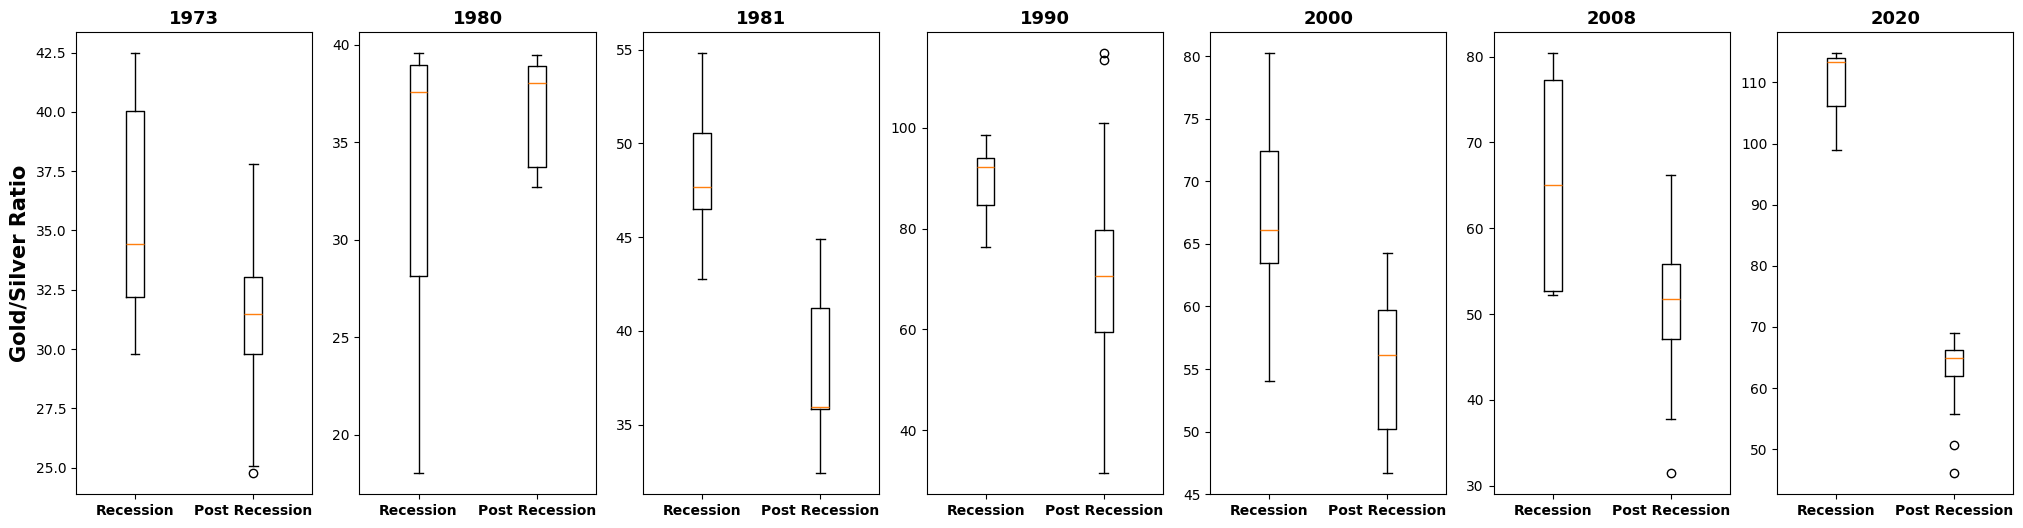

In [ ]:
fig, axes = plt.subplots(1, 7, figsize=(25, 6))
axes[0].boxplot([recession_1973_df['Gold/Silver Ratio'], post_recession_1973_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[0].set_title('1973', fontweight = 'bold', fontsize = 13)
axes[1].boxplot([recession_1980_df['Gold/Silver Ratio'], post_recession_1980_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[1].set_title('1980', fontweight = 'bold', fontsize = 13)
axes[2].boxplot([recession_1981_df['Gold/Silver Ratio'], post_recession_1981_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[2].set_title('1981', fontweight = 'bold', fontsize = 13)
axes[3].boxplot([recession_1990_df['Gold/Silver Ratio'], post_recession_1990_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[3].set_title('1990', fontweight = 'bold', fontsize = 13)
axes[4].boxplot([recession_2000_df['Gold/Silver Ratio'], post_recession_2000_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[4].set_title('2000', fontweight = 'bold', fontsize = 13)
axes[5].boxplot([recession_2008_df['Gold/Silver Ratio'], post_recession_2008_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[5].set_title('2008', fontweight = 'bold', fontsize = 13)
axes[6].boxplot([recession_2020_df['Gold/Silver Ratio'], post_recession_2020_df['Gold/Silver Ratio']], labels = ['Recession', 'Post Recession'])
axes[6].set_title('2020', fontweight = 'bold', fontsize = 13)

axes[0].set_ylabel('Gold/Silver Ratio', fontweight ='bold', fontsize = 15)
axes[0].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[1].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[2].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[3].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[4].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[5].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
axes[6].set_xticklabels(['Recession', 'Post Recession'], fontweight='bold')
#plt.title("Comparison of Gold/Silver Ratios Across Recessionary and Post-Recessionary Periods (Accounting for Lag)")
#plt.show()

In [ ]:
denominator_sum = np.mean(recession_1973_df['Gold/Silver Ratio']) + np.mean(recession_1980_df['Gold/Silver Ratio']) + np.mean(recession_1981_df['Gold/Silver Ratio']) + np.mean(recession_1990_df['Gold/Silver Ratio']) + np.mean(recession_2000_df['Gold/Silver Ratio']) + np.mean(recession_2008_df['Gold/Silver Ratio']) + np.mean(recession_2020_df['Gold/Silver Ratio'])
numerator_sum = np.mean(post_recession_1973_df['Gold/Silver Ratio']) + np.mean(post_recession_1980_df['Gold/Silver Ratio']) + np.mean(post_recession_1981_df['Gold/Silver Ratio']) + np.mean(post_recession_1990_df['Gold/Silver Ratio']) + np.mean(post_recession_2000_df['Gold/Silver Ratio']) + np.mean(post_recession_2008_df['Gold/Silver Ratio'])+ np.mean(post_recession_2020_df['Gold/Silver Ratio'])
moderate_case = numerator_sum/denominator_sum
moderate_case
1-moderate_case

np.float64(0.22987524860818598)

In [ ]:
q3_denom = recession_1973_df['Gold/Silver Ratio'].quantile(0.75) + recession_1980_df['Gold/Silver Ratio'].quantile(0.75) + recession_1981_df['Gold/Silver Ratio'].quantile(0.75) + recession_1990_df['Gold/Silver Ratio'].quantile(0.75) + recession_2000_df['Gold/Silver Ratio'].quantile(0.75) + recession_2008_df['Gold/Silver Ratio'].quantile(0.75) + recession_2020_df['Gold/Silver Ratio'].quantile(0.75)
q1_num = post_recession_1973_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_1980_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_1981_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_1990_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_2000_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_2008_df['Gold/Silver Ratio'].quantile(0.25) + post_recession_2020_df['Gold/Silver Ratio'].quantile(0.25)
bull_case = q1_num/q3_denom
bull_case
1-bull_case

np.float64(0.34763701480657117)

In [ ]:
q3_num = post_recession_1973_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_1980_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_1981_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_1990_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_2000_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_2008_df['Gold/Silver Ratio'].quantile(0.75) + post_recession_2020_df['Gold/Silver Ratio'].quantile(0.75)
q1_denom = recession_1973_df['Gold/Silver Ratio'].quantile(0.25) + recession_1980_df['Gold/Silver Ratio'].quantile(0.25) + recession_1981_df['Gold/Silver Ratio'].quantile(0.25) + recession_1990_df['Gold/Silver Ratio'].quantile(0.25) + recession_2000_df['Gold/Silver Ratio'].quantile(0.25) + recession_2008_df['Gold/Silver Ratio'].quantile(0.25) + recession_2020_df['Gold/Silver Ratio'].quantile(0.25)
bear_case = q3_num/q1_denom
bear_case
1-bear_case

np.float64(0.09508625465125264)